 Projectile Motion Engineering Helper 
This program analyzes a projectile launched
in 2D using basic physics and plots its path.
Assumes Earth gravity g = 9.81 m/s^2.

Enter projectile parameters:
  Initial speed v0 (m/s), must be > 0: 10
  Launch angle (degrees above horizontal, e.g. 45): 45
  Initial height y0 (m), must be >= 0: 20

Results for this projectile:
  Time of flight     : 2.86 s
  Maximum height     : 22.55 m
  Horizontal range   : 20.26 m
  Impact speed       : 22.19 m/s

Do you want to analyze another projectile after viewing this graph? (y/n): n
This will be the last graph. Exiting after plot...


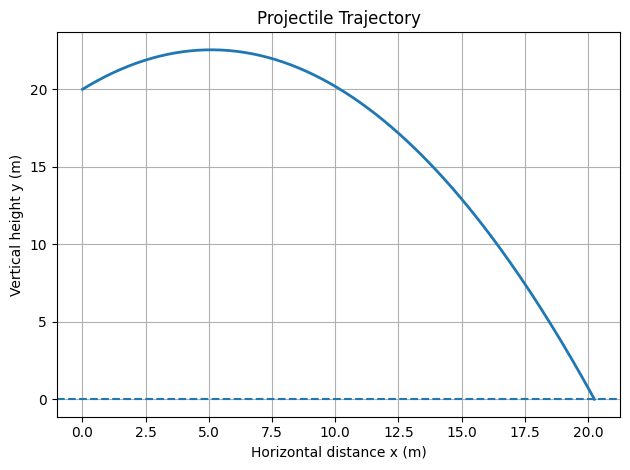

In [ ]:
###############################################
# Program: Projectile Motion Engineering Calculator
# Author: Tuyen Nguyen
# Date: 2025-11-28
# Description:
#   This program analyzes projectile motion
#   for engineering-style problems. The user
#   enters launch speed, angle, and initial
#   height. The program computes time of flight,
#   maximum height, horizontal range, and impact
#   speed, and plots the trajectory using NumPy
#   and Matplotlib (assuming Earth gravity g=9.81 m/s^2).
###############################################

"""
PSEUDOCODE

1. Import external packages:
   - numpy as np for numerical computing
   - matplotlib.pyplot as plt for plotting

2. Define a function get_float_input(prompt, min_value=None, max_value=None):
   - Use a while loop with try/except to get a valid float.
   - Enforce optional min/max bounds if provided.

3. Define a function compute_projectile_motion(v0, angle_deg, y0=0.0, g=9.81):
   - Convert angle to radians.
   - Compute vx, vy0.
   - Solve y(t) = y0 + vy0*t - 0.5*g*t^2 = 0 using numpy.roots.
   - Keep only positive real roots and take the largest as time of flight.
   - Make time array, compute x(t), y(t).
   - Compute max height, range, impact speed.
   - Return all results in a dictionary.

4. Define a function plot_trajectory(x_vals, y_vals):
   - Create a new figure.
   - Plot x vs y with labels, title, grid, and y=0 line.
   - Show the plot.

5. In main():
   - Print welcome message.
   - Set run_again = True and start while loop.
   - For each loop:
       a) Ask for v0, angle, y0 using get_float_input.
       b) Call compute_projectile_motion.
       c) Print time of flight, max height, range, impact speed.
       d) Ask user if they want to analyze another projectile (y/n)
          and set run_again accordingly.
       e) Plot the trajectory.
   - End program when run_again is False.

6. Use if __name__ == "__main__": main() at bottom.
"""

# IMPORTS AND CONSTANTS

import numpy as np
import matplotlib.pyplot as plt

# USER-DEFINED FUNCTIONS

def get_float_input(prompt, min_value=None, max_value=None):
    """
    Ask the user to enter a floating-point number with optional range checks.
    """
    while True:
        user_text = input(prompt)

        try:
            value = float(user_text)

            if (min_value is not None) and (value < min_value):
                print(f"Value must be at least {min_value}. Please try again.")
                continue

            if (max_value is not None) and (value > max_value):
                print(f"Value must be at most {max_value}. Please try again.")
                continue

            return value

        except ValueError:
            print("That was not a valid number. Please enter a numeric value.")


def compute_projectile_motion(v0, angle_deg, y0=0.0, g=9.81):
    """
    Compute basic projectile motion quantities for a launch in 2D.

    Assumes:
    - Constant gravitational acceleration g (downward)
    - No air resistance
    - Flat ground at y = 0
    """
    # Convert launch angle from degrees to radians
    angle_rad = np.deg2rad(angle_deg)

    # Horizontal and vertical components of initial velocity
    vx = v0 * np.cos(angle_rad)
    vy0 = v0 * np.sin(angle_rad)

    # Coefficients for y(t) = y0 + vy0*t - 0.5*g*t^2
    # Solve -0.5*g*t^2 + vy0*t + y0 = 0 → a*t^2 + b*t + c = 0
    a = -0.5 * g
    b = vy0
    c = y0

    # Quadratic roots
    roots = np.roots([a, b, c])

    # Keep positive real roots
    t_candidates = []
    for r in roots:
        if np.isreal(r):
            t_val = float(np.real(r))
            if t_val > 0:
                t_candidates.append(t_val)

    if len(t_candidates) == 0:
        raise ValueError("No positive time of flight found. Check input values.")

    # Time of flight is largest positive root
    t_flight = max(t_candidates)

    # Time array
    t_vals = np.linspace(0.0, t_flight, 200)

    # Position arrays
    x_vals = vx * t_vals
    y_vals = y0 + vy0 * t_vals - 0.5 * g * t_vals**2

    # Time at max height vy(t) = vy0 - g*t = 0 → t = vy0/g
    t_peak = vy0 / g
    if t_peak < 0:
        t_peak = 0.0
    h_max = y0 + vy0 * t_peak - 0.5 * g * t_peak**2

    # Range and impact speed
    x_range = vx * t_flight
    vy_final = vy0 - g * t_flight
    vx_final = vx
    v_impact = np.sqrt(vx_final**2 + vy_final**2)

    return {
        "t_flight": t_flight,
        "h_max": h_max,
        "x_range": x_range,
        "v_impact": v_impact,
        "t_vals": t_vals,
        "x_vals": x_vals,
        "y_vals": y_vals
    }


def plot_trajectory(x_vals, y_vals):
    """
    Plot the projectile trajectory using Matplotlib.
    """
    plt.figure()
    plt.plot(x_vals, y_vals, linewidth=2)
    plt.xlabel("Horizontal distance x (m)")
    plt.ylabel("Vertical height y (m)")
    plt.title("Projectile Trajectory")
    plt.grid(True)
    plt.axhline(0, linestyle="--")
    plt.tight_layout()
    plt.show()


# MAIN PROGRAM LOGIC


def main():
    """
    Main function that runs the interactive projectile motion helper.
    """
    print("======================================")
    print(" Projectile Motion Engineering Helper ")
    print("======================================")
    print("This program analyzes a projectile launched")
    print("in 2D using basic physics and plots its path.")
    print("Assumes Earth gravity g = 9.81 m/s^2.")
    print()

    run_again = True

    while run_again:
        print("Enter projectile parameters:")

        v0 = get_float_input(
            "  Initial speed v0 (m/s), must be > 0: ",
            min_value=0.01
        )

        angle_deg = get_float_input(
            "  Launch angle (degrees above horizontal, e.g. 45): ",
            min_value=-10.0,
            max_value=89.0
        )

        y0 = get_float_input(
            "  Initial height y0 (m), must be >= 0: ",
            min_value=0.0
        )

        print()

        try:
            results = compute_projectile_motion(v0, angle_deg, y0)

            t_flight = results["t_flight"]
            h_max = results["h_max"]
            x_range = results["x_range"]
            v_impact = results["v_impact"]

            print("Results for this projectile:")
            print(f"  Time of flight     : {t_flight:.2f} s")
            print(f"  Maximum height     : {h_max:.2f} m")
            print(f"  Horizontal range   : {x_range:.2f} m")
            print(f"  Impact speed       : {v_impact:.2f} m/s")

        except ValueError as err:
            print("Error while computing projectile motion:")
            print(f"  {err}")
            # If computation failed, still ask if user want to try again
            print()
            answer = input("Do you want to try another projectile? (y/n): ")
            if len(answer) > 0 and answer[0].lower() == "y":
                run_again = True
                print()
                continue
            else:
                run_again = False
                print("Exiting program. Goodbye!")
                break

        # Ask user whether to keep computing or not
        print()
        answer = input("Do you want to analyze another projectile after plotting graph? (y/n): ")
        if len(answer) > 0 and answer[0].lower() == "y":
            run_again = True
        else:
            run_again = False
            print("This will be the last graph. Exiting after plot...")

        # Now show the plot for this run
        plot_trajectory(results["x_vals"], results["y_vals"])
        print()  # space before next loop or exit


if __name__ == "__main__":
    main()
